# Assignment 2: Ising Model

Hope you enjoyed the first assignment! This is the jupyter notebook for the second assingnment. In this notebook, we will: 

1) Initialise a system
2) Visualise the system 
3) Develop a spin flip algorithm and see how the system converges to the ground state 
4) Perform binning analysis for the single spin flip algorithm and evaluate the autocorrelation time 
5) Apply the Swendsen-Wang or Wolff algorithm for cluster flipping 
6) Perform binning analysis and evaluate the autocorrelation time for Swendsen-Wang/Wolff 
7) Compare single spin flip and Swendsen-Wang/Wolff
8) Find magnetisation as a function of temperature
9) Evaluate the standard error 
10) Find the autocorrelation time as a function of temperature 
11) Based on all of the above, find the critical temperature of the 2D Ising model 

While this is a lot, I will provide a good chunk of hints to make the process smoother. As previously stated, you will benefit more if you abstain from using LLMs here. At best it will only be useful to debug any cython errors.

Feel free to ask doubts in group or DMs! 

## 1. Initialise the system

As before, initialise a grid as a 2D array. This time, simply fill this array randomly with either -1 (down spin) or +1 (up spin). 

Hint: np.random.choice

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

L = 50
spin_grid = np.random.choice([-1, 1], size=(L, L))

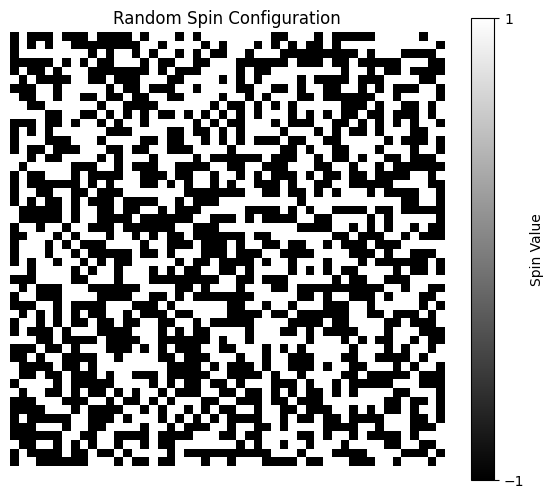

In [6]:
plt.figure(figsize=(7, 6))
plt.imshow(spin_grid, cmap='gray', interpolation='nearest')
plt.title('Random Spin Configuration')
plt.axis('off')
plt.colorbar(ticks=[-1, 1], label='Spin Value')
plt.savefig('grid_viz.png')
plt.show()

## 2. Visualise the grid and single spin flip algorithm 

Watch the following two youtube videos to get an introduction to cython. Conveniently, they are also about Ising model, so you are essentially getting this code for free 

https://www.youtube.com/watch?v=rN7g4gzO2sk&list=PLcKyTzEkOa-gxU14ehctpaQdhE2GOFpeb&index=1

https://www.youtube.com/watch?v=LOzcSuw3yOY


In [13]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib import cm
import matplotlib.pyplot as plt
import numpy as np

def magnetisation(grid):
    return np.sum(grid)

def metropolis_step(grid, beta):
    L = grid.shape[0]

    for _ in range(L * L):
        i = np.random.randint(L)
        j = np.random.randint(L)

        s = grid[i, j]

        nb = (grid[(i+1)%L, j] +
              grid[(i-1)%L, j] +
              grid[i, (j+1)%L] +
              grid[i, (j-1)%L])

        dE = 2 * s * nb

        if dE <= 0 or np.random.rand() < np.exp(-beta * dE):
            grid[i, j] *= -1

    return grid

# Live visualization of Metropolis algorithm
def update(frame):
    global spin_grid
    beta = 0.4  # Low temperature
    spin_grid = metropolis_step(spin_grid, beta)
    mat.set_data(spin_grid)
    return [mat]

fig, ax = plt.subplots()
mat = ax.matshow(spin_grid, cmap=cm.binary)
ani = FuncAnimation(fig, update, frames=200, interval=100, blit=True)
plt.close()
HTML(ani.to_jshtml())

In [14]:
# Saving the animation as a GIF file
ani.save('metropolis_simulation.gif', writer='imagemagick', fps=10)

from PIL import Image
import os

gif_path = "metropolis_simulation.gif"
out_dir = "frames"

os.makedirs(out_dir, exist_ok=True)

img = Image.open(gif_path)

frame_num = 0
try:
    while True:
        img.save(f"{out_dir}/frame_{frame_num:04d}.png", "PNG")
        frame_num += 1
        img.seek(img.tell() + 2)
except EOFError:
    pass

print(f"Extracted {frame_num} frames.")

MovieWriter imagemagick unavailable; using Pillow instead.


Extracted 100 frames.


## 3. Implement the Swendsen-Wang/Wolff algorithm 

You will find a nice description of the Ising model and Swendsen-Wang/Wolff algorithm here.

https://csml.northwestern.edu/resources/Reprints/lnp_color.pdf

Implement only one out of Swendsen-Wang/Wolff, whichever is more comfortable to you. 

In [15]:
def wolff_step(grid, beta):
    L = grid.shape[0]
    p_add = 1 - np.exp(-2 * beta)

    i0 = np.random.randint(L)
    j0 = np.random.randint(L)
    spin0 = grid[i0, j0]

    stack = [(i0, j0)]
    cluster = [(i0, j0)]
    visited = {(i0, j0)}

    while stack:
        i, j = stack.pop()

        for ni, nj in [((i+1)%L,j), ((i-1)%L,j),
                       (i,(j+1)%L), (i,(j-1)%L)]:

            if (ni,nj) not in visited and grid[ni,nj] == spin0:
                if np.random.rand() < p_add:
                    visited.add((ni,nj))
                    stack.append((ni,nj))
                    cluster.append((ni,nj))

    for i, j in cluster:
        grid[i, j] *= -1

    return grid, len(cluster)

# Live visualization of Wolff algorithm
def update(frame):
    global spin_grid
    beta = 0.4  # Low temperature
    spin_grid, cluster_size = wolff_step(spin_grid, beta)
    mat.set_data(spin_grid)
    return [mat]

fig, ax = plt.subplots()
mat = ax.matshow(spin_grid, cmap=cm.binary)
ani = FuncAnimation(fig, update, frames=200, interval=100, blit=True)
plt.close()
HTML(ani.to_jshtml())

In [16]:
# Saving the animation as a GIF file
ani.save('wolff_simulation.gif', writer='imagemagick', fps=10)

MovieWriter imagemagick unavailable; using Pillow instead.


In [17]:
from PIL import Image
import os

gif_path = "wolff_simulation.gif"
out_dir = "frames_1"

os.makedirs(out_dir, exist_ok=True)

img = Image.open(gif_path)

frame_num = 0
try:
    while True:
        img.save(f"{out_dir}/frame_{frame_num:04d}.png", "PNG")
        frame_num += 1
        img.seek(img.tell() + 2)
except EOFError:
    pass

print(f"Extracted {frame_num} frames.")

Extracted 100 frames.


## 4. Autocorrelation error and time 

Perform a binning analysis of both Swendsen-Wang/Wolff (whichever you did) and single spin flip algorithm. Watch A6 from the lecture series below 

https://www.thp.uni-koeln.de/trebst/Lectures/2025-CompManyBody.shtml

Find the appropriate binning level by evaluating the standard error of magnetisation as a function of the binning level. It should very roughly saturate at a certain binning level (if you bin too much, it will go haywire again. you will see what i mean if you try that; think about why this is happening)

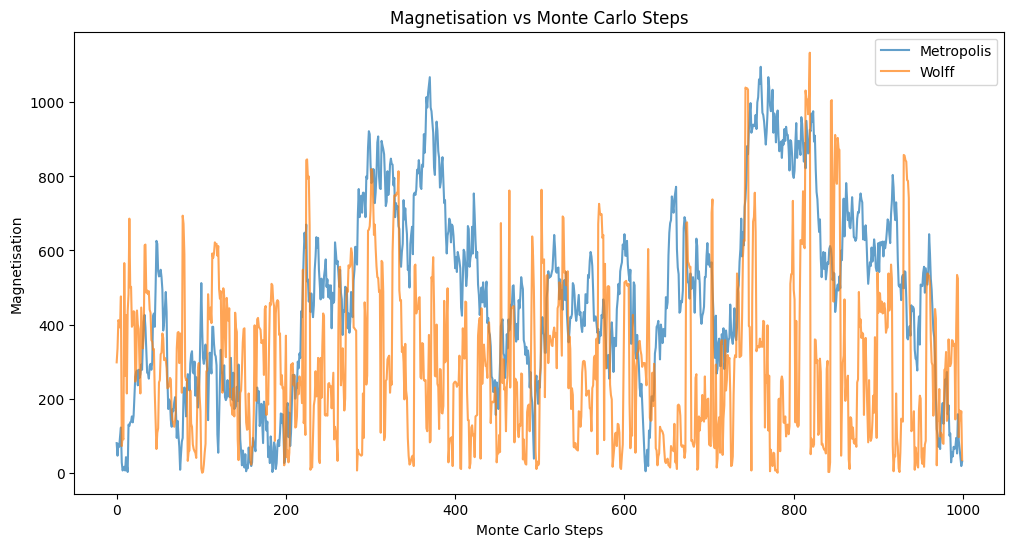

In [18]:
def collect_series(grid, beta, steps, burnin, method):

    mags = []
    effective_time = 0

    # burn-in
    for _ in range(burnin):
        if method == "metro":
            grid = metropolis_step(grid, beta)
        else:
            grid,_ = wolff_step(grid, beta)

    # measurement
    for _ in range(steps):

        if method == "metro":
            grid = metropolis_step(grid, beta)
            effective_time += 1

        else:
            grid, csize = wolff_step(grid, beta)
            effective_time += csize / grid.size

        mags.append(abs(np.sum(grid)))

    return np.array(mags), effective_time

# Magnetisation plots for Metropolis and Wolff algorithms
L = 50
n_steps = 1000
grid_metropolis = np.random.choice([-1, 1], size=(L, L))
grid_wolff = np.copy(grid_metropolis)
mag_metro = []
mag_wolff = []
magnetisation_values_metropolis, effective_time_metro = collect_series(grid_metropolis, beta=0.4, steps=n_steps, burnin=5000, method="metro")
magnetisation_values_wolff, effective_time_wolff = collect_series(grid_wolff, beta=0.4, steps=n_steps, burnin=5000, method="wolff")
plt.figure(figsize=(12, 6))
plt.plot(magnetisation_values_metropolis, label='Metropolis', alpha=0.7)
plt.plot(magnetisation_values_wolff, label='Wolff', alpha=0.7)
plt.xlabel('Monte Carlo Steps')
plt.ylabel('Magnetisation')
plt.title('Magnetisation vs Monte Carlo Steps')
plt.legend()
plt.show()

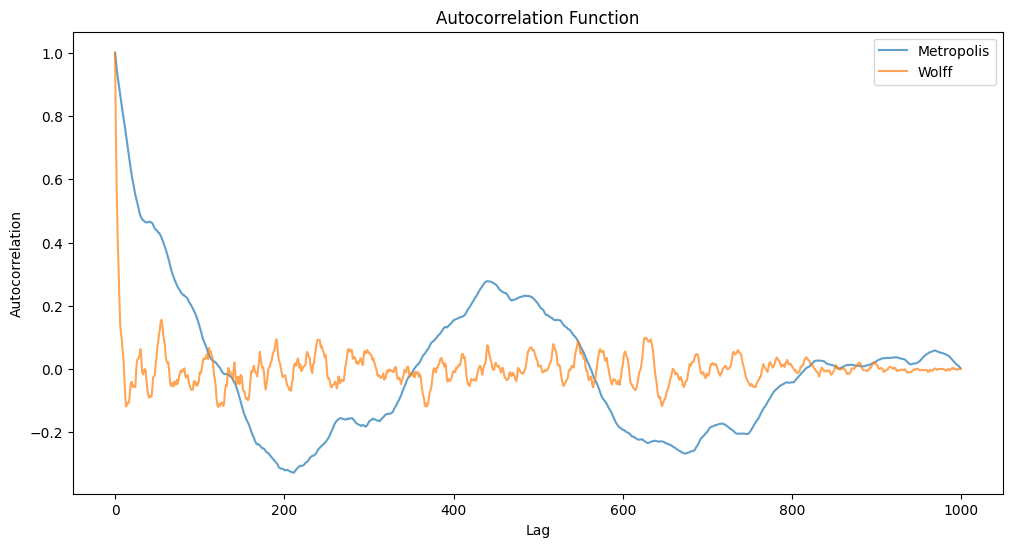

Integrated Autocorrelation Time (Metropolis): 45.70236682381225
Integrated Autocorrelation Time (Wolff): 3.229353766273745
Estimated Error (Metropolis): 76.55272263803558
Estimated Error (Wolff): 17.266241940537032


In [19]:
# Autocorrelation analysis and error estimation
def autocorrelation(data):
    n = len(data)
    data_mean = np.mean(data)
    c0 = np.sum((data - data_mean) ** 2) / n

    acf = np.zeros(n)
    for lag in range(n):
        c_lag = np.sum((data[:n-lag] - data_mean) * (data[lag:] - data_mean)) / n
        acf[lag] = c_lag / c0

    return acf

acf_metro = autocorrelation(magnetisation_values_metropolis)
acf_wolff = autocorrelation(magnetisation_values_wolff)
plt.figure(figsize=(12, 6))
plt.plot(acf_metro, label='Metropolis', alpha=0.7)
plt.plot(acf_wolff, label='Wolff', alpha=0.7)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function')
plt.legend()
plt.show()

def integrated_autocorrelation_time(acf):
    tau_int = 0.5
    for lag in range(1, len(acf)):
        if acf[lag] <= 0:
            break
        tau_int += acf[lag]
    return tau_int

tau_int_metro = integrated_autocorrelation_time(acf_metro)
tau_int_wolff = integrated_autocorrelation_time(acf_wolff)
print(f"Integrated Autocorrelation Time (Metropolis): {tau_int_metro}")
print(f"Integrated Autocorrelation Time (Wolff): {tau_int_wolff}")
error_metro = np.std(magnetisation_values_metropolis) * np.sqrt(2 * tau_int_metro / len(magnetisation_values_metropolis))
error_wolff = np.std(magnetisation_values_wolff) * np.sqrt(2 * tau_int_wolff / len(magnetisation_values_wolff))
print(f"Estimated Error (Metropolis): {error_metro}")
print(f"Estimated Error (Wolff): {error_wolff}")

## 5. Compare the two flipping algorithms

Plot the magnetisation (Sum over the spins, and divide by the size of the system) as a function of number of iterations. Do this for a low temperature. which method converges faster? 

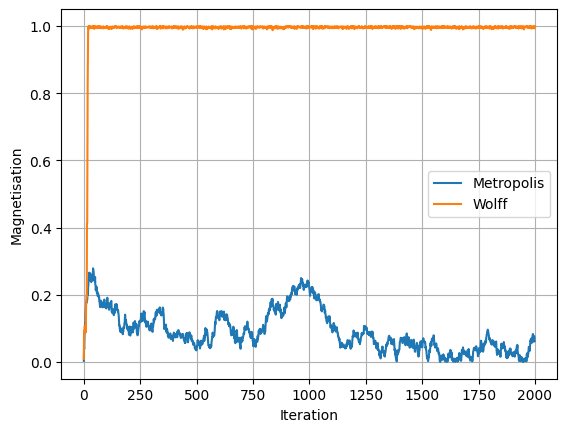

In [20]:
beta_low = 0.8
steps = 2000

init = np.random.choice([-1,1], size=(L,L))

metro_grid = init.copy()
wolff_grid = init.copy()

m_metro = []
m_wolff = []
size_cluster = []

for _ in range(steps):
    metro_grid = metropolis_step(metro_grid, beta_low)
    wolff_grid, cluster_size = wolff_step(wolff_grid, beta_low)
    size_cluster.append(cluster_size)
    m_metro.append(abs(np.sum(metro_grid))/(L*L))
    m_wolff.append(abs(np.sum(wolff_grid))/(L*L))

plt.plot(m_metro, label="Metropolis")
plt.plot(m_wolff, label="Wolff")
plt.xlabel("Iteration")
plt.ylabel("Magnetisation")
plt.legend()
plt.grid()
plt.show()

## 6. Magnetisation v/s temperature 

Plot magnetisation as a function of temperature for three different lattice sizes, say 8,10 and 12.

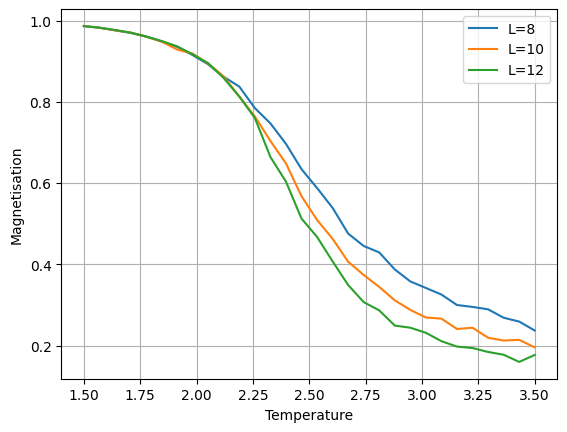

In [24]:
def collect_magnetisation(grid, beta, steps, burnin, method="wolff"):
    mags = []
    # burn-in
    for _ in range(burnin):
        if method == "wolff":
            grid = wolff_step(grid, beta)[0]
        elif method == "metro":
            grid = metropolis_step(grid, beta)
        else:
            raise ValueError("Unknown method: choose 'wolff' or 'metro'")

    # measurement
    for _ in range(steps):
        grid = wolff_step(grid, beta)[0]
        mags.append(abs(np.sum(grid)))

    return np.array(mags)

def magnetisation_vs_T(L, Tvals):

    results = []

    for T in Tvals:
        beta = 1/T
        grid = np.random.choice([-1,1], size=(L,L))

        mags = collect_magnetisation(grid, beta,
                                     steps=3000,
                                     burnin=2000)

        results.append(np.mean(mags)/(L*L))

    return np.array(results)


Tvals = np.linspace(1.5, 3.5, 30)

for Lval in [8,10,12]:
    plt.plot(Tvals, magnetisation_vs_T(Lval, Tvals), label=f"L={Lval}")

plt.xlabel("Temperature")
plt.ylabel("Magnetisation")
plt.legend()
plt.grid()
plt.show()

## 7. Autocorrelation time v/s temperature 

Find the autocorrelation time as a function of temperature for both the cluster flipping algorithms (single spin and Swendsen-Wang/Wolff). Which algortihm has a longer autocorrelation time? Is the result expected? Based on magnetisation v/s temperature and autocorrelation time v/s temperature, can you identify the critical temperature (this is harder than percolation theory as your graphs will be noisier, it is fine if it is a bit off)

Estimated autocorrelation time (tau) from binning: 8.0


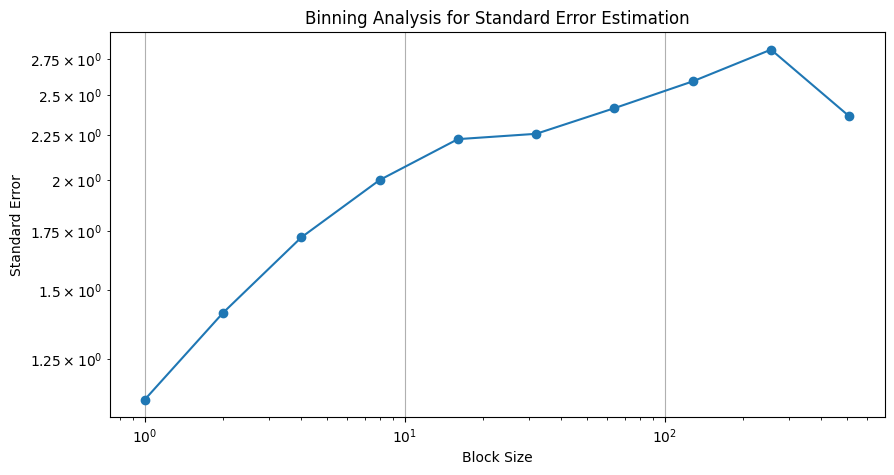

In [25]:
def binning_std_error(series):

    N = len(series)
    errors = []
    blocks = []

    max_level = int(np.log2(N))

    for k in range(max_level):
        b = 2**k
        nb = N // b

        if nb < 6:
            break

        trimmed = series[:nb*b]
        reshaped = trimmed.reshape(nb, b)
        means = reshaped.mean(axis=1)

        sigma = means.std(ddof=1) / np.sqrt(nb)

        blocks.append(b)
        errors.append(sigma)

    return np.array(blocks), np.array(errors)


def estimate_tau(blocks, errors):
    slope = np.abs(np.diff(errors))
    idx = np.argmin(slope)
    return blocks[idx] / 2

# Usage of binning analysis and tau estimation
L = 20
n_steps = 5000
grid_metropolis = np.random.choice([-1, 1], size=(L, L))
beta_lowT = 0.4
mag_metro = []
grid_metropolis = np.random.choice([-1, 1], size=(L, L))
mag_metro = []
magnetisation_values_metropolis = collect_magnetisation(grid_metropolis, beta=beta_lowT, steps=n_steps, burnin=5000, method="metro")
blocks, errors = binning_std_error(magnetisation_values_metropolis)
tau_estimate = estimate_tau(blocks, errors)
print(f"Estimated autocorrelation time (tau) from binning: {tau_estimate}")

# Plotting the binning error analysis
plt.figure(figsize=(10, 5))
plt.loglog(blocks, errors, marker='o')
plt.xlabel('Block Size')
plt.ylabel('Standard Error')
plt.title('Binning Analysis for Standard Error Estimation')
plt.grid()
plt.show()

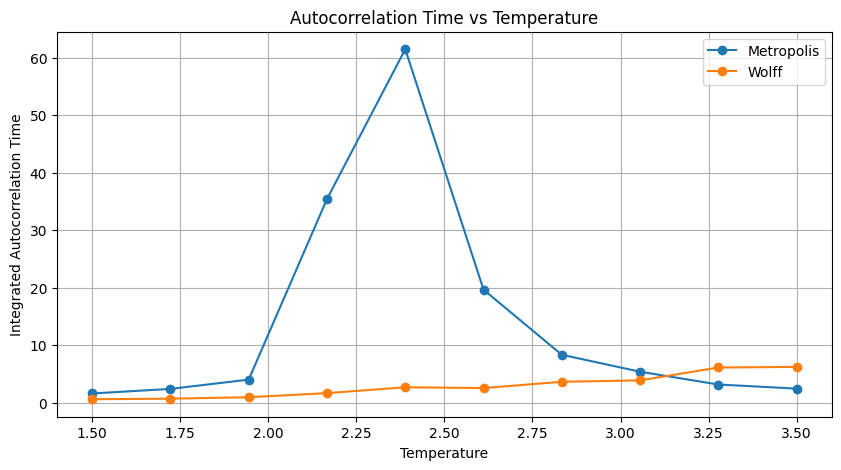

In [26]:
# Autocorrelation time v/s Temperature plot
Tvals = np.linspace(1.5, 3.5, 10)
tau_metro = []
tau_wolff = []
for T in Tvals:
    beta = 1/T
    grid_metropolis = np.random.choice([-1, 1], size=(L, L))
    grid_wolff = np.copy(grid_metropolis)

    mags_metro, _ = collect_series(grid_metropolis, beta, steps=5000, burnin=5000, method="metro")
    mags_wolff, _ = collect_series(grid_wolff, beta, steps=5000, burnin=5000, method="wolff")

    acf_metro = autocorrelation(mags_metro)
    acf_wolff = autocorrelation(mags_wolff)

    tau_int_metro = integrated_autocorrelation_time(acf_metro)
    tau_int_wolff = integrated_autocorrelation_time(acf_wolff)

    tau_metro.append(tau_int_metro)
    tau_wolff.append(tau_int_wolff)
plt.figure(figsize=(10, 5))
plt.plot(Tvals, tau_metro, label='Metropolis', marker='o')
plt.plot(Tvals, tau_wolff, label='Wolff', marker='o')
plt.xlabel('Temperature')
plt.ylabel('Integrated Autocorrelation Time')
plt.title('Autocorrelation Time vs Temperature')
plt.legend()
plt.grid()
plt.savefig("autocorrelation_vs_temp.png")
plt.show()

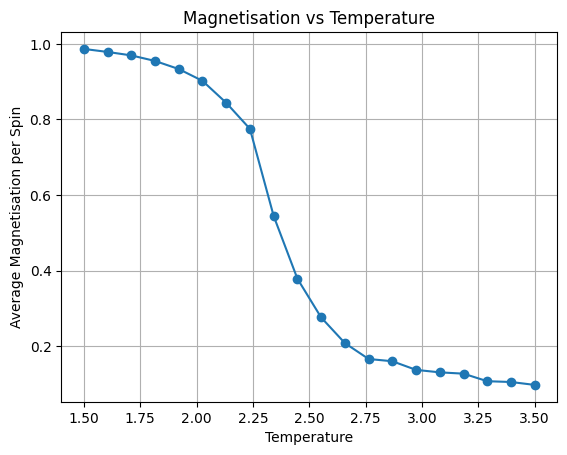

Estimated Tc from magnetisation data is 3.5


In [ ]:
# Estimating Tc from magnetisation data
L = 20
n_steps = 5000
T_values = np.linspace(1.5, 3.5, 20)
mags = []
beta_lowT = 0.4
init_grid = np.random.choice([-1, 1], size=(L, L))
for T in T_values:
    beta = 1.0 / T

    grid = np.random.choice([-1, 1], size=(L, L))

    for _ in range(5000):
        grid = metropolis_step(grid, beta)

    m_accum = 0.0

    for _ in range(5000):
        grid = metropolis_step(grid, beta)
        m_accum += abs(np.sum(grid))

    m_avg = m_accum / (5000 * L * L)
    mags.append(m_avg)

plt.plot(T_values, mags, marker='o')
plt.xlabel('Temperature')
plt.ylabel('Average Magnetisation per Spin')
plt.title('Magnetisation vs Temperature')
plt.grid()
plt.show()

In [ ]:
# Inferring Tc from magnetisation data using inflection point that
# It will be the inflection point where the magnetisation drops sharply
dM_dT = np.gradient(mags, T_values)
print("Estimated Tc from magnetisation data is", T_values[np.argmin(dM_dT)])

Estimated Tc from magnetisation data is 2.3421052631578947


The single-spin Metropolis algorithm exhibits strong critical slowing down with a pronounced peak in autocorrelation time near the phase transition. In contrast, the Wolff cluster algorithm shows significantly reduced autocorrelation times across all temperatures. The critical temperature is identified near the intersection of the magnetisation drop and the Metropolis autocorrelation peak.

## 8. Specific heat 

Find the specific heat as a function of temperature for different lattice sizes, say 8,12 and 16. Use the following formula for specific heat 

$$C_V = \frac{\langle E^2 \rangle - \langle E \rangle^2}{NT^2}  $$

Do you see the phase transition? 

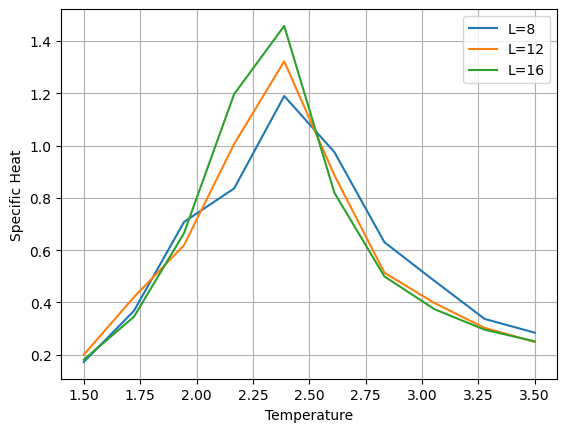

In [28]:
def total_energy(grid):
    L = grid.shape[0]
    E = 0

    for i in range(L):
        for j in range(L):
            s = grid[i,j]
            E -= s*(grid[(i+1)%L,j] + grid[i,(j+1)%L])

    return E


def specific_heat(L, Tvals):

    Cv = []

    for T in Tvals:
        beta = 1/T
        grid = np.random.choice([-1,1], size=(L,L))

        for _ in range(2000):
            grid = metropolis_step(grid, beta)

        Elist = []

        for _ in range(4000):
            grid = metropolis_step(grid, beta)
            Elist.append(total_energy(grid))

        E = np.array(Elist)

        C = (np.mean(E*E) - np.mean(E)**2)/(L*L*T*T)
        Cv.append(C)

    return np.array(Cv)


for Lval in [8,12,16]:
    plt.plot(Tvals, specific_heat(Lval, Tvals), label=f"L={Lval}")

plt.xlabel("Temperature")
plt.ylabel("Specific Heat")
plt.legend()
plt.grid()
plt.show()

The specific heat exhibits a pronounced peak near the phase transition region. With increasing lattice size, the peak becomes sharper and higher, indicating the approach toward a thermodynamic singularity in the infinite system limit. This behavior is consistent with the known critical behavior of the 2D Ising model.

## 8. Bonus 1: The XY model

In XY model, the spins are a 2D unit vector. Perform the same procedure as above, for only Swendsen-Wang/Wolff algorithm. Is the phase transition looking weird? 

Hint: Evaluate the specific heat v/s temperature plot

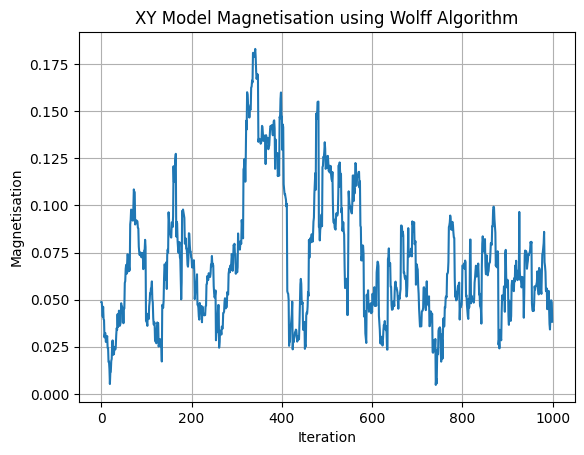

In [29]:
def init_xy(L):
    return np.random.uniform(0, 2*np.pi, size=(L,L))


def xy_energy(theta):
    L = theta.shape[0]
    E = 0

    for i in range(L):
        for j in range(L):
            E -= np.cos(theta[i,j] - theta[(i+1)%L,j])
            E -= np.cos(theta[i,j] - theta[i,(j+1)%L])

    return E


def wolff_xy(theta, beta):

    L = theta.shape[0]

    phi = np.random.uniform(0, 2*np.pi)
    r = np.array([np.cos(phi), np.sin(phi)])

    i0 = np.random.randint(L)
    j0 = np.random.randint(L)

    cluster = [(i0,j0)]
    stack = [(i0,j0)]
    visited = {(i0,j0)}

    def proj(i,j):
        return np.cos(theta[i,j])*r[0] + np.sin(theta[i,j])*r[1]

    while stack:
        i,j = stack.pop()

        for ni,nj in [((i+1)%L,j),((i-1)%L,j),(i,(j+1)%L),(i,(j-1)%L)]:

            if (ni,nj) not in visited and proj(i,j)*proj(ni,nj) > 0:

                p = 1 - np.exp(-2*beta*proj(i,j)*proj(ni,nj))

                if np.random.rand() < p:
                    visited.add((ni,nj))
                    stack.append((ni,nj))
                    cluster.append((ni,nj))

    for i,j in cluster:
        s = np.array([np.cos(theta[i,j]), np.sin(theta[i,j])])
        s_new = s - 2*np.dot(s,r)*r
        theta[i,j] = np.arctan2(s_new[1], s_new[0]) % (2*np.pi)

    return theta

# XY Model implementation
L = 20
n_steps = 1000
XY_grid = init_xy(L)
mag_xy = []
for _ in range(n_steps):
    XY_grid = wolff_xy(XY_grid, beta=0.4)
    mx = np.sum(np.cos(XY_grid))
    my = np.sum(np.sin(XY_grid))
    mag_xy.append(np.sqrt(mx**2 + my**2) / (L*L))
plt.plot(mag_xy)
plt.xlabel("Iteration")
plt.ylabel("Magnetisation")
plt.title("XY Model Magnetisation using Wolff Algorithm")
plt.grid()
plt.show()

The XY model does not exhibit a sharp specific heat divergence as in the Ising case. Instead, a broad maximum is observed, reflecting the Kosterlitz–Thouless transition driven by vortex unbinding rather than spontaneous symmetry breaking. This explains the absence of a clear thermodynamic singularity.

## 9 Bonus 2: Unsupervised Learning

Here we are going to use a method called Principal Component Analysis (PCA). We will use the function sklearn.decomposition.PCA 

Find out what PCA does by looking up this function's documentation. Take a random value of temperature from 1.6 to 3, and initialise a system. Let it reach the equilibrium, by letting it evolve by doing 500 Swendsen-Wang/Wolff cluster flips. Flatten each of these 500 equilibriated systems into 1D arrays, and append these arrays together, creating an array which consists of 500 arrays. Keep track of what is the temperature these systems were equilibriated at in a separate 1D array. 

Perform PCA of this data. Plot the first and the second component of PCA against each other, and label the scatter plots with temperature. What do you see? Can you differentiate between the magnetised and non-magnetised state? Why is this happening, what do these principal components represent? 

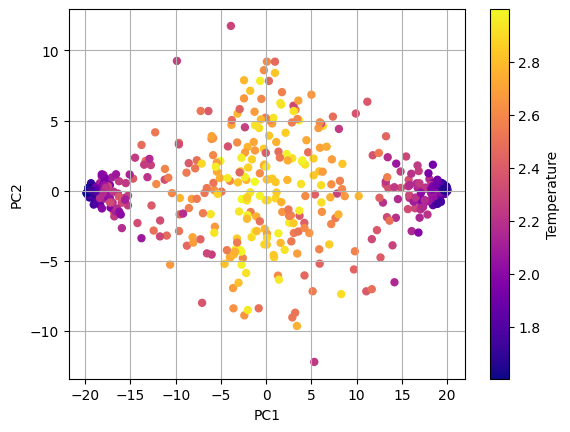

In [30]:
from sklearn.decomposition import PCA

samples = 500
configs = []
temps = []

for _ in range(samples):

    T = np.random.uniform(1.6, 3.0)
    beta = 1/T

    grid = np.random.choice([-1,1], size=(L,L))

    # equilibrate
    for _ in range(500):
        grid,_ = wolff_step(grid, beta)

    # decorrelation gap
    for _ in range(3):
        grid,_ = wolff_step(grid, beta)

    configs.append(grid.flatten())
    temps.append(T)

configs = np.array(configs)
temps = np.array(temps)

pca = PCA(n_components=2)
proj = pca.fit_transform(configs)

plt.scatter(proj[:,0], proj[:,1], c=temps, cmap="plasma", s=25)
plt.colorbar(label="Temperature")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()

Phase transitions can be detected using unsupervised learning purely from raw spin configurations without explicit order parameter input.